In [3]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Definted Function Method For Cleaning List
# def clean_list(skill_list):
#     if pd.notna(skill_list):
#         return ast.literal_eval(skill_list)

# df['job_skills'] =  df['job_skills'].apply(clean_list)

In [8]:
df_exploded = df.explode('job_skills').copy()

<Axes: xlabel='job_skills'>

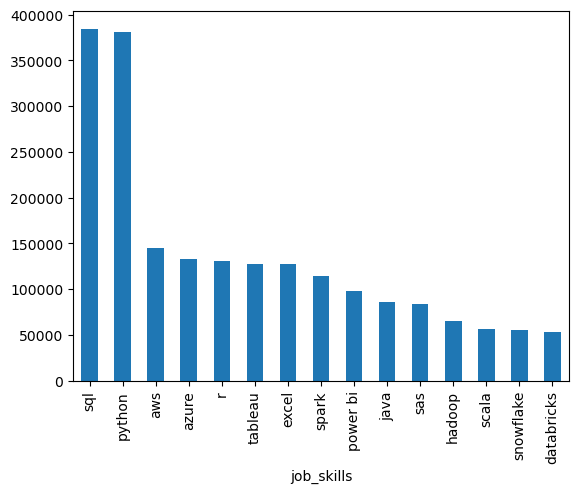

In [10]:
df_exploded['job_skills'].value_counts().head(15).plot(kind='bar')

In [15]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).agg('size')

In [16]:
df_skills_count = skills_count.reset_index(name='skill_count')

In [21]:
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)

In [32]:
job_title = 'Data Engineer'
top_skills = 10

df_skills_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skills)

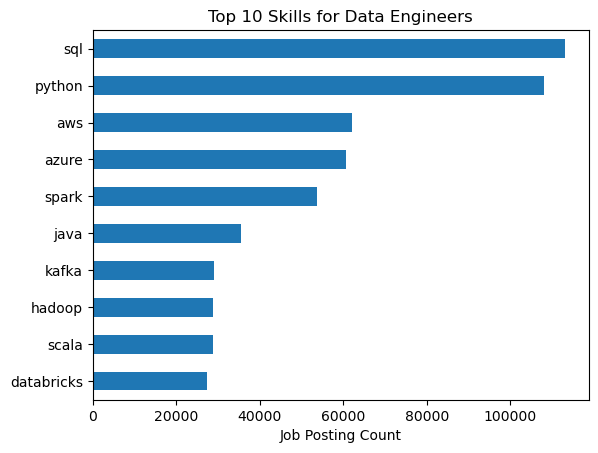

In [35]:
df_skills_final.plot(kind='barh', x='job_skills', y='skill_count')

plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)

plt.show()